## HYPERPARAMETER TUNING HEATMAP — MASTER CODE

### Imports & Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

sns.set(style="whitegrid")
np.random.seed(42)


In [ ]:
# Dataset
data = load_breast_cancer()
X = data.data
y = data.target


### Pipeline + Grid Search

In [3]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

param_grid = {
    "svm__C": np.logspace(-2, 3, 6),
    "svm__gamma": np.logspace(-4, 1, 6)
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X, y)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': array([1.e-02...e+02, 1.e+03]), 'svm__gamma': array([1.e-04...e+00, 1.e+01])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

### Convert Grid Results to Heatmap Matrix

In [4]:
results = pd.DataFrame(grid.cv_results_)

heatmap_data = results.pivot(
    index="param_svm__gamma",
    columns="param_svm__C",
    values="mean_test_score"
)


### Hyperparameter Tuning Heatmap (Validation Accuracy)

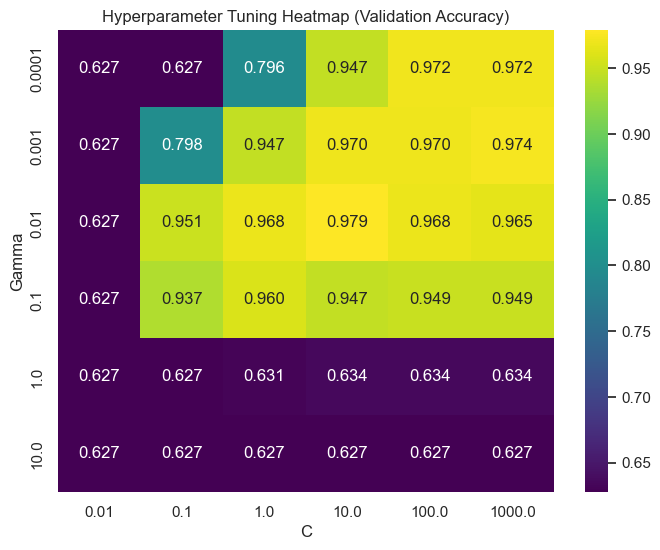

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)
plt.title("Hyperparameter Tuning Heatmap (Validation Accuracy)")
plt.xlabel("C")
plt.ylabel("Gamma")
plt.show()


### Training vs Validation Heatmap (Overfitting Diagnosis)

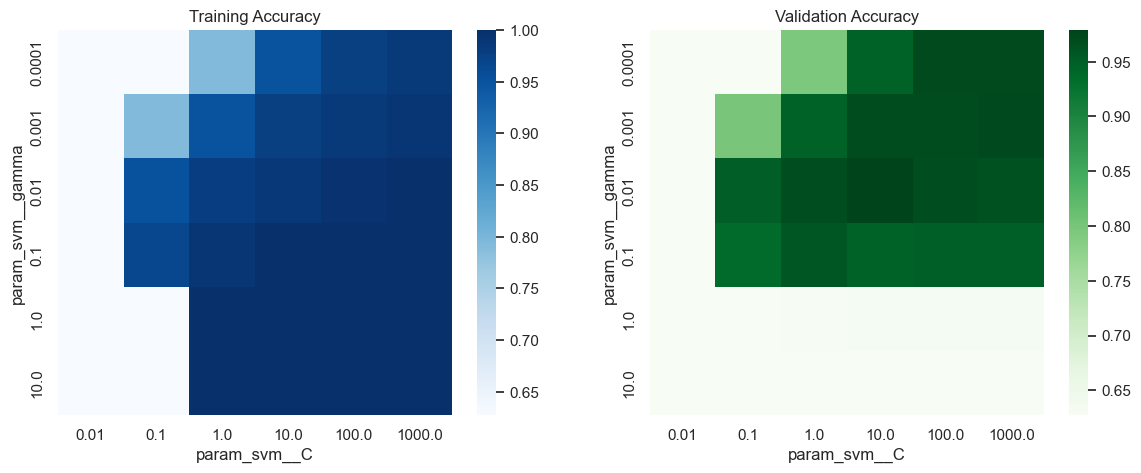

In [7]:
train_heatmap = results.pivot(
    index="param_svm__gamma",
    columns="param_svm__C",
    values="mean_train_score"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    train_heatmap,
    annot=False,
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Training Accuracy")

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="Greens",
    ax=axes[1]
)
axes[1].set_title("Validation Accuracy")

plt.show()


### Heatmap with Best Region Highlighted

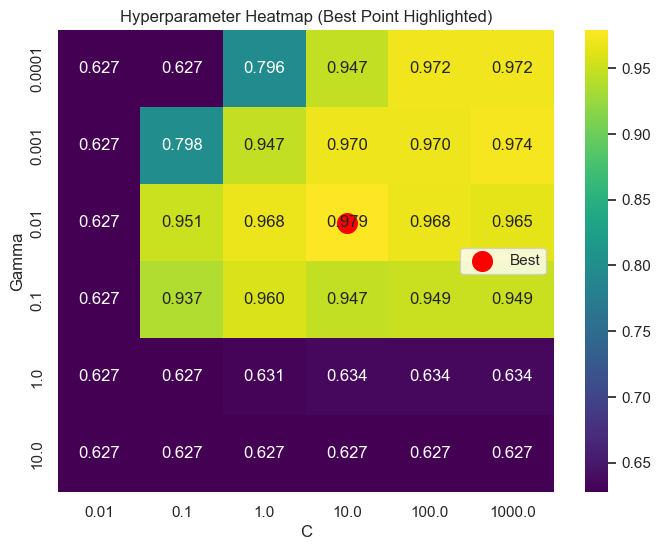

In [8]:
best_gamma = grid.best_params_["svm__gamma"]
best_C = grid.best_params_["svm__C"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=True,
    fmt=".3f"
)

gamma_idx = list(heatmap_data.index).index(best_gamma)
C_idx = list(heatmap_data.columns).index(best_C)

plt.scatter(
    C_idx + 0.5,
    gamma_idx + 0.5,
    color="red",
    s=200,
    marker="o",
    label="Best"
)

plt.legend()
plt.title("Hyperparameter Heatmap (Best Point Highlighted)")
plt.xlabel("C")
plt.ylabel("Gamma")
plt.show()
